# Heart_Disease_Detection

## Information of Dataset
> This dataset is taken from the Cleveland Heart Disease database(kaggle).
> It contains medical attributes of patients and predicts whether they have heart disease or not.

1. **Age** :
- Represents the age of the patient in years.
- Higher age generally increases the risk of heart disease. 

2. **sex** :
- Indicates the gender of the patient (0 = Female, 1 = Male).
- Men are statistically more prone to heart disease than women.

3. **cp (Chest Pain Type)** :
- Describes the type of chest pain experienced by the patient.
- Certain types of chest pain are strongly associated with heart disease.

4. **trestbps (Resting Blood Pressure)** :
- Blood pressure measured when the patient is at rest (mm Hg).
- High resting blood pressure increases heart disease risk.

5. **chol (Serum Cholesterol)** :
- Cholesterol level in the blood (mg/dl).
- High cholesterol can cause blockage in arteries.

6. **fbs (Fasting Blood Sugar)** :
- Indicates whether fasting blood sugar is above 120 mg/dl (1 = Yes, 0 = No).
- High blood sugar may indicate diabetes, a risk factor for heart disease.

7. **restecg (Resting ECG-Electrocardiographic Results)** :
- Results of the electrocardiogram test taken at rest.
- Abnormal ECG patterns may indicate heart problems.

8. **thalach (Maximum Heart Rate Achieved)** :
- The highest heart rate recorded during exercise testing.
- Lower maximum heart rate may indicate heart dysfunction.

9. **exang (Exercise-Induced Angina)** :
- Indicates whether the patient experienced chest pain during exercise (1 = Yes, 0 = No).
- Exercise-induced chest pain is a strong indicator of heart disease.

10. **oldpeak (ST Depression)** :
- ST depression induced by exercise relative to rest.
- Higher values suggest abnormal heart function during stress.

11. **slope** :
- Slope of the peak exercise ST segment.
- Certain slope patterns are linked to heart abnormalities.

12. **ca (Number of Major Vessels)** :
- Number of major blood vessels colored by fluoroscopy (0–3).
- More blocked vessels increase the likelihood of heart disease.

13. **thal (Thalassemia Test Result)** :
- Result of the thalassemia blood test.
- Abnormal results may indicate higher heart disease risk.

14. **condition (Target Variable)** :
- Indicates presence of heart disease (1 = Disease, 0 = No Disease).
- This is the variable we aim to predict using logistic regression.

In [1]:
# importing library
import pandas as pd

In [2]:
df = pd.read_csv("heart_cleveland_upload.csv")

In [3]:
df.shape

(297, 14)

In [4]:
df.head()
# Top rows of dataset

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [5]:
df.columns
# shows all the column names

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'condition'],
      dtype='object')

In [6]:
df.info()
# The dataset contains 297 records and 14 attributes.
# After checking for missing values, no null values were found in any column.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


In [7]:
df['condition'].value_counts()
# condition(target variable) represents the presence of heart disease:(1 = Disease, 0 = No Disease).
# overall 160 patients without heart disease and 137 patients with heart disease.

condition
0    160
1    137
Name: count, dtype: int64

In [8]:
# EDA(Exploratory Data Analysis) is where you understand the story of the data.
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


In [9]:
##  EDA Understandings  ##
# Mean Age ≈ 54.5 years
# The average age of patients is approximately 54 years, indicating that the dataset mainly consists of middle-aged(40-50) individuals.
# chol = 564 is extremely high.
# Normal cholesterol:(Below 200 → desirable, 200–239 → borderline, 240+ → high)
# Maximum Heart Rate(thalach):- Min = 71, Max = 202, Mean ≈ 149
# 71 is very low max heart rate → may indicate heart dysfunction. Wide range suggests strong predictive potential.

In [10]:
corr_condition = df.corr()['condition']

In [11]:
corr_condition

age          0.227075
sex          0.278467
cp           0.408945
trestbps     0.153490
chol         0.080285
fbs          0.003167
restecg      0.166343
thalach     -0.423817
exang        0.421355
oldpeak      0.424052
slope        0.333049
ca           0.463189
thal         0.520516
condition    1.000000
Name: condition, dtype: float64

> Correlation Analysis
- Correlation analysis revealed that thal (0.52) and ca (0.46) showed the strongest positive correlation with heart disease.
- Maximum heart rate achieved(thalach) showed a strong negative correlation (-0.42), indicating that lower maximum heart rate is associated with higher disease probability.
- Chol and fbs showed weak correlation with the target variable in this dataset.

In [12]:
# importing libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
corr_matrix = df.corr()

In [14]:
corr_matrix

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
age,1.000000,-0.092399,0.110471,0.290476,0.202644,0.132062,0.149917,-0.394563,0.096489,0.197123,0.159405,0.362210,0.120795,0.227075
sex,-0.092399,1.000000,0.008908,-0.066340,-0.198089,0.038850,0.033897,-0.060496,0.143581,0.106567,0.033345,0.091925,0.370556,0.278467
cp,0.110471,0.008908,1.000000,-0.036980,0.072088,-0.057663,0.063905,-0.339308,0.377525,0.203244,0.151079,0.235644,0.266275,0.408945
trestbps,0.290476,-0.066340,-0.036980,1.000000,0.131536,0.180860,0.149242,-0.049108,0.066691,0.191243,0.121172,0.097954,0.130612,0.153490
chol,0.202644,-0.198089,0.072088,0.131536,1.000000,0.012708,0.165046,-0.000075,0.059339,0.038596,-0.009215,0.115945,0.023441,0.080285
fbs,0.132062,0.038850,-0.057663,0.180860,0.012708,1.000000,0.068831,-0.007842,-0.000893,0.008311,0.047819,0.152086,0.051038,0.003167
restecg,0.149917,0.033897,0.063905,0.149242,0.165046,0.068831,1.000000,-0.072290,0.081874,0.113726,0.135141,0.129021,0.013612,0.166343
thalach,-0.394563,-0.060496,-0.339308,-0.049108,-0.000075,-0.007842,-0.072290,1.000000,-0.384368,-0.347640,-0.389307,-0.268727,-0.258386,-0.423817
exang,0.096489,0.143581,0.377525,0.066691,0.059339,-0.000893,0.081874,-0.384368,1.000000,0.289310,0.250572,0.148232,0.323268,0.421355
oldpeak,0.197123,0.106567,0.203244,0.191243,0.038596,0.008311,0.113726,-0.347640,0.289310,1.000000,0.579037,0.294452,0.336809,0.424052


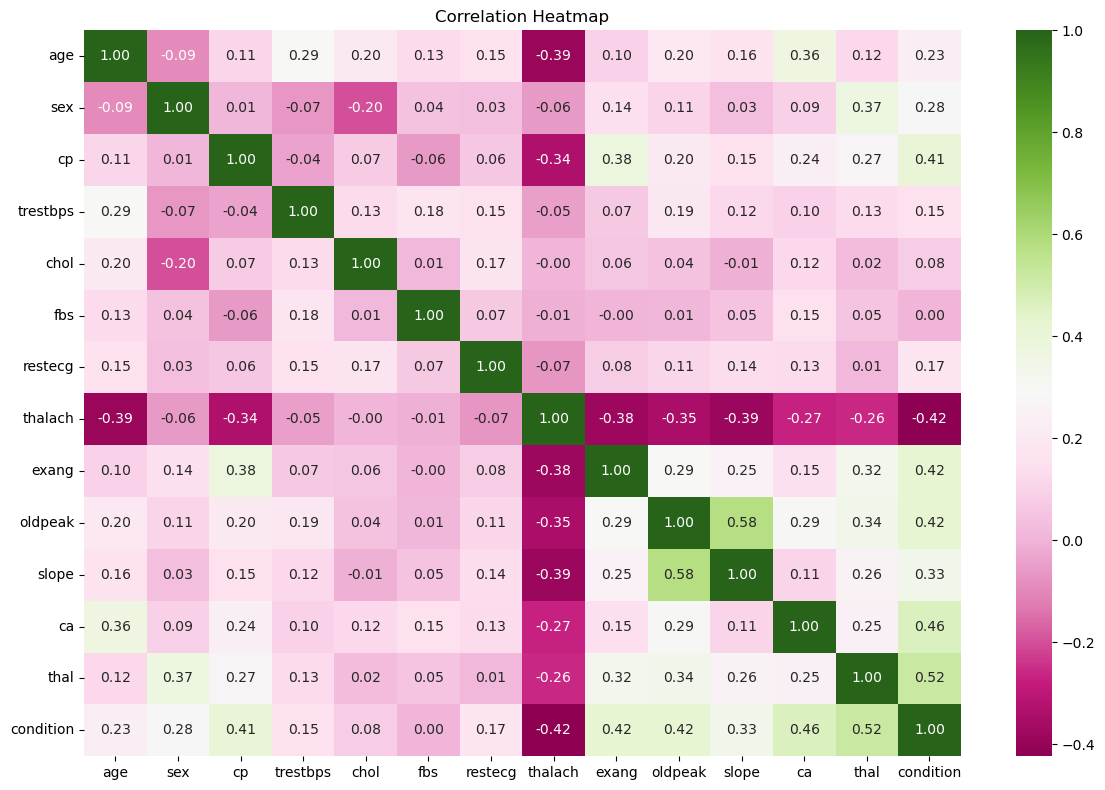

In [15]:
plt.figure(figsize = (12,8))
sns.heatmap(corr_matrix,annot = True,cmap = 'PiYG', fmt = '.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

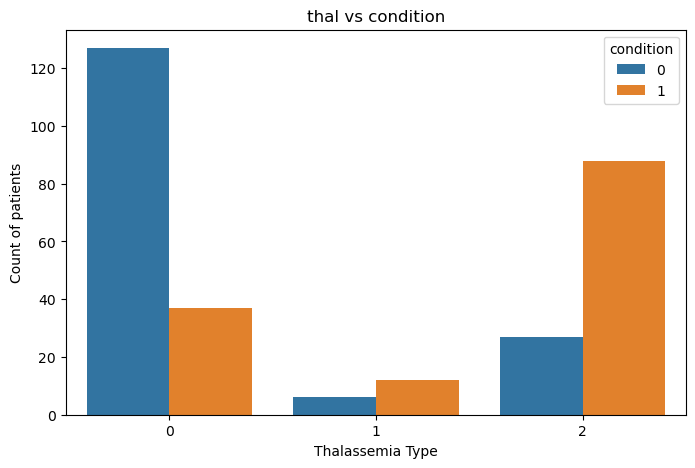

In [16]:
# 1.thal vs condition
plt.figure(figsize =(8,5))
sns.countplot(x='thal',hue='condition',data =df)
plt.title("thal vs condition")
plt.xlabel("Thalassemia Type")
plt.ylabel("Count of patients")
plt.show();

- Thal vs Condition
- (0, 1, 2)-These are thal categories.
- Thal = 0 : Mostly No Disease, Very few disease cases.(strong indicator of healthy group)
- Thal = 1 : Small group, Slightly more disease than no disease.
- Thal = 2 : Majority are Disease cases, Much higher orange bar.(strong indicator of heart disease)
- Patients with thalassemia category 2 show significantly higher heart disease prevalence, while category 0 mostly corresponds to non-disease cases. This confirms strong predictive power of thal.

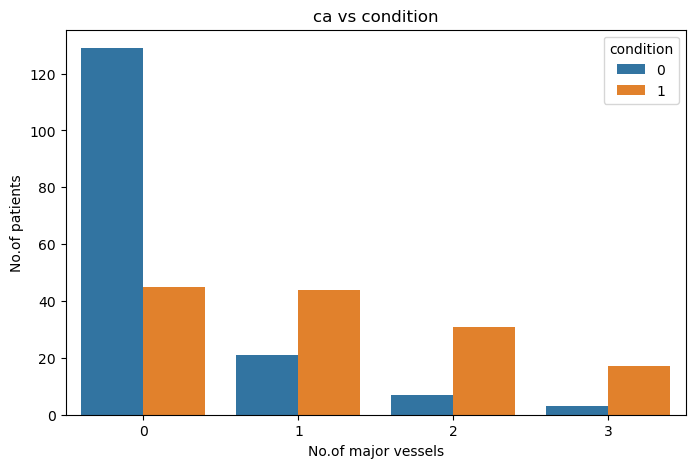

In [17]:
# 2. ca vs condition
plt.figure(figsize = (8,5))
sns.countplot(data=df,x='ca',hue='condition')
plt.title('ca vs condition')
plt.xlabel('No.of major vessels')
plt.ylabel('No.of patients')
plt.show();

- ca = 0 → Mostly No Disease
- ca = 1 → More Disease than No Disease
- ca = 2 → Mostly Disease
- ca = 3 → Very strong Disease dominance
- As the number of major vessels increases, the proportion of heart disease cases increases significantly.
- Patients with 2 and 3 vessels show strong dominance of the disease class.

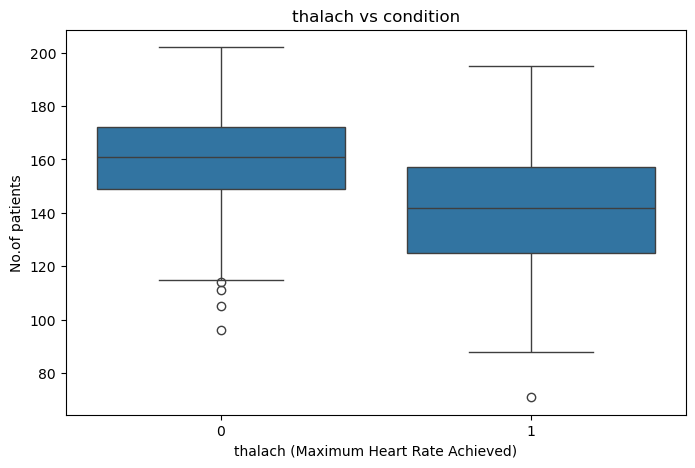

In [18]:
# 3. thalach vs condition
plt.figure(figsize=(8,5))
#sns.countplot(data=df, x='thalach',hue='condition')
sns.boxplot(x='condition', y='thalach', data=df)
plt.title("thalach vs condition")
plt.xlabel('thalach (Maximum Heart Rate Achieved)')
plt.ylabel('No.of patients')
plt.show();

- Condition 0 (No Disease) 
- Condition 1 (Disease)
- No Disease median ≈ around 160, Disease median ≈ around 140
- disease group median is clearly lower.
- Patients with heart disease generally achieve lower maximum heart rate.
- Lower exercise capacity → higher chance of heart disease.
- Boxplot analysis revealed that patients with heart disease have significantly lower median maximum heart rate achieved compared to non-disease patients. This confirms the negative correlation observed earlier (-0.42), making thalach a strong predictor.

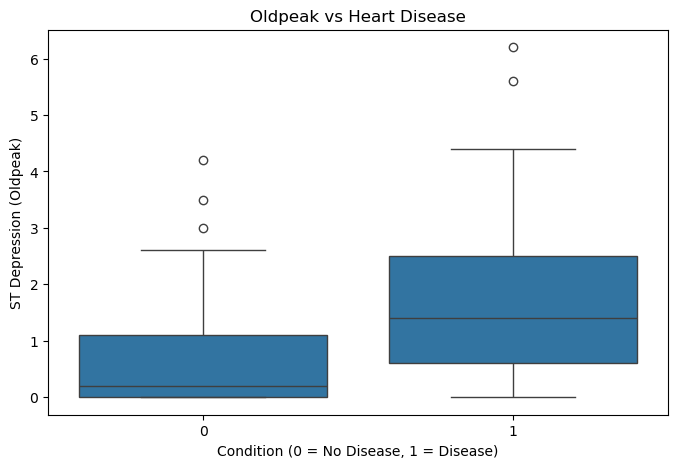

In [19]:
# 4. Oldpeak vs condition
plt.figure(figsize=(8,5))
sns.boxplot(x='condition', y='oldpeak', data=df)
plt.title("Oldpeak vs Heart Disease")
plt.xlabel("Condition (0 = No Disease, 1 = Disease)")
plt.ylabel("ST Depression (Oldpeak)")

plt.show()

- oldpeak increases → probability of disease increases.
- thalach increases → probability of disease decreases.
- ST depression (oldpeak) showed significantly higher median and distribution in the disease group, confirming its strong positive correlation (0.42) with heart disease. This aligns with medical interpretation, as higher ST depression indicates abnormal cardiac stress response.
  

## EDA Analysis
- thal (strong categorical predictor)
- ca (monotonic categorical predictor)
- thalach (strong negative continuous predictor)
- oldpeak (strong positive continuous predictor)

| Step     | Purpose                                     |
| -------- | ------------------------------------------- |
| Encoding | Convert categorical values into numbers     |
| Scaling  | Normalize numerical values to similar range |


- y scaling is recommended:-
1️. Faster convergence during optimization
2️. More stable gradient descent
3️. Better regularization behavior
4️. Easier interpretation of coefficients

> Train-Test Split and Feature Scaling

Before building the logistic regression model, the dataset was divided into training and testing sets.
The split was performed first to prevent data leakage and ensure that the model does not learn from unseen test data.

Feature scaling was then applied to continuous variables. The scaler was fitted only on the training data and later used to transform both training and testing datasets.
This approach ensures that the model generalizes properly without using information from the test set during preprocessing.

In [20]:
# Train-Test Split

X = df.drop('condition', axis = 1)
Y = df['condition']

# Why Do We Use 80-20 Instead of 50-50?
# We want more data for training while still keeping enough data for testing. Machine learning models learn patterns from data.
# 80% → Enough data to learn patterns
# 20% → Enough unseen data to evaluate generalization

In [21]:
# importing model (Train-Test Split)
from sklearn.model_selection import train_test_split

In [22]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size = 0.2,
    random_state =42,
    stratify = Y
)

In [23]:
# X_train, X_test, Y_train, Y_test

In [24]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (237, 13)
X_test shape: (60, 13)


In [25]:
print("\nTraining class distribution:")
print(Y_train.value_counts())

print("\nTesting class distribution:")
print(Y_test.value_counts())

# The dataset was split into 80% training and 20% testing data.
# Stratified sampling was used to preserve class distribution.
# The training and testing sets maintain nearly identical class proportions,
# ensuring fair and unbiased model evaluation.


Training class distribution:
condition
0    128
1    109
Name: count, dtype: int64

Testing class distribution:
condition
0    32
1    28
Name: count, dtype: int64


In [26]:
# Training Logistic Regression model
# import warnings
# warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [27]:
# Making predictions
Y_pred = model.predict(X_test)

In [28]:
Y_pred

array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1])

In [29]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(Y_test, Y_pred)
accuracy

0.9166666666666666

In [30]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, Y_pred)
cm

array([[32,  0],
       [ 5, 23]])

In [31]:
from sklearn.metrics import classification_report

print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.86      1.00      0.93        32
           1       1.00      0.82      0.90        28

    accuracy                           0.92        60
   macro avg       0.93      0.91      0.91        60
weighted avg       0.93      0.92      0.92        60



In [32]:
# Model evaluation was performed using accuracy, confusion matrix,
# and classification report to assess overall performance and
# class-wise prediction quality.

# The logistic regression model achieved 91.6% accuracy on the test set.
# The confusion matrix shows zero false positives and only 5 false negatives.
# Precision for the disease class is 1.00, indicating no incorrect disease predictions.
# Recall for the disease class is 0.82, meaning the model detected 82% of actual disease cases.
# Overall, the model demonstrates strong predictive performance.

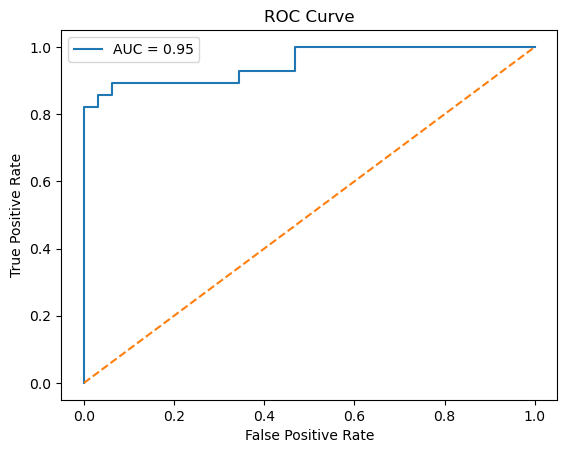

In [36]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

Y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(Y_test, Y_prob)
auc_score = roc_auc_score(Y_test, Y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

#ROC Curve and AUC Evaluation

# The Receiver Operating Characteristic(ROC) curve was plotted to evaluate the model's ability to distinguish between patients with and without heart disease.
# The ROC curve shows the relationship between the True Positive Rate(Recall) and the False Positive Rate at different classification thresholds.
# The Area Under the Curve(AUC) score was calculated to quantify the model's classification performance. The model achieved an AUC score of approximately 0.95, indicating excellent discriminative ability.
# An AUC value close to 1.0 suggests that the model is highly capable of distinguishing between the two classes(heart disease vs no heart disease).

In [37]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients.sort_values(by="Coefficient", ascending=False)

# Feature Importance Interpretation

# The coefficients of the Logistic Regression model were analyzed to understand how each feature influences the prediction of heart disease.
# Positive coefficients indicate features that increase the probability of heart disease, while negative coefficients indicate features associated with a lower predicted risk.
# Among the features, the number of major vessels (ca), exercise-induced angina (exang), sex, and thalassemia (thal) showed the strongest influence on the model's predictions. 
# These variables play a significant role in determining the likelihood of heart disease in the dataset.
# Feature importance analysis helps improve model interpretability and provides insights into the key factors associated with heart disease risk.

,Feature,Coefficient
11,ca,1.046272
8,exang,0.811524
1,sex,0.674641
12,thal,0.623206
2,cp,0.498027
9,oldpeak,0.379075
10,slope,0.321332
6,restecg,0.139467
3,trestbps,0.017048
4,chol,0.002918


In [38]:
# Feature Importance Interpretation:
# The logistic regression coefficients reveal that the number of major vessels (ca), exercise-induced angina (exang), sex, and thalassemia (thal) are among the strongest predictors of heart disease in the dataset.
# Positive coefficients indicate features that increase the probability of heart disease, while negative coefficients indicate features associated with lower predicted risk.
# Among all variables, the number of major vessels colored by fluoroscopy (ca) shows the strongest influence on the model’s prediction, suggesting a strong relationship with heart disease presence.

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Fit on training data
X_train_scaled = scaler.fit_transform(X_train)
# Transform test data
X_test_scaled = scaler.transform(X_test)

In [46]:
import numpy as np

# Example patient data
new_patient = np.array([[54,1,2,130,250,0,1,150,0,1.2,2,0,2]])
# Scale the input
new_patient_scaled = scaler.transform(new_patient)
# Make prediction
prediction = model.predict(new_patient_scaled)
print("Predicted Class:", prediction)
if prediction[0] == 1:
    print("Prediction: Patient likely has heart disease")
else:
    print("Prediction: Patient likely does NOT have heart disease")

Predicted Class: [0]
Prediction: Patient likely does NOT have heart disease


C:\Users\abhil\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\abhil\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
